Epoch 0, Loss: 0.138814, Training Accuracy: 51.88%
Epoch 10, Loss: 0.158415, Training Accuracy: 51.88%
Epoch 20, Loss: 0.094312, Training Accuracy: 56.88%
Epoch 30, Loss: 0.015422, Training Accuracy: 98.75%
Epoch 40, Loss: 0.013752, Training Accuracy: 96.88%
Epoch 50, Loss: 0.006950, Training Accuracy: 99.38%
Epoch 60, Loss: 0.004460, Training Accuracy: 100.00%
Epoch 70, Loss: 0.003471, Training Accuracy: 100.00%
Epoch 80, Loss: 0.002911, Training Accuracy: 100.00%
Epoch 90, Loss: 0.002539, Training Accuracy: 100.00%

训练集最终准确率：100.00%
验证集准确率：100.00%


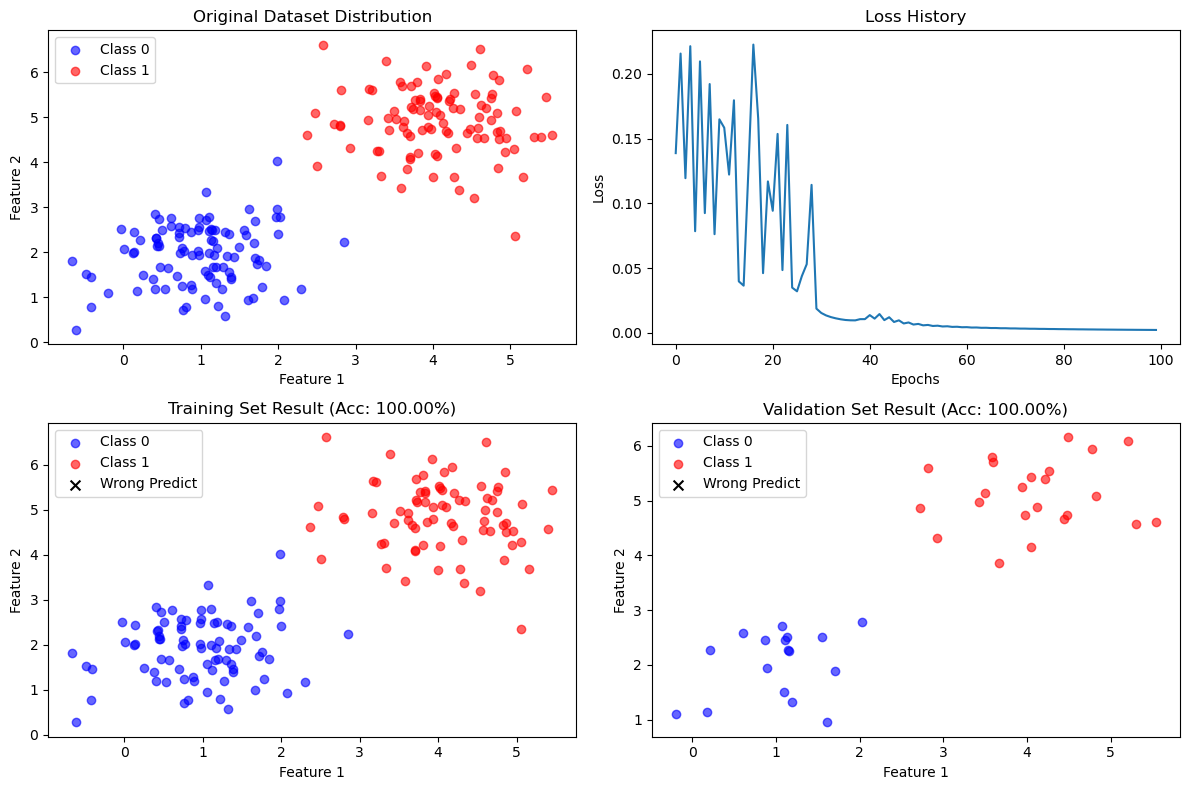

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 用于划分训练集和验证集（也可手动划分，这里用现成工具更便捷）
from sklearn.model_selection import train_test_split

# 1. 定义Sigmoid激活函数及其导数（反向传播需要）
def sigmoid(x):
    """Sigmoid激活函数，输出范围(0,1)"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Sigmoid函数的导数，推导式：sigmoid(x)*(1-sigmoid(x))"""
    s = sigmoid(x)
    return s * (1 - s)

# 2. 定义BP神经网络类
class BPNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # 初始化权重（随机数，范围-1到1）
        self.weights_input_hidden = np.random.uniform(-1, 1, (input_size, hidden_size))  # 输入层到隐藏层的权重：input_size x hidden_size
        self.weights_hidden_output = np.random.uniform(-1, 1, (hidden_size, output_size))  # 隐藏层到输出层的权重：hidden_size x output_size
        
        # 初始化偏置（初始为0）
        self.bias_hidden = np.zeros((1, hidden_size))  # 隐藏层偏置：1 x hidden_size
        self.bias_output = np.zeros((1, output_size))  # 输出层偏置：1 x output_size
        
        # 学习率（超参数）
        self.learning_rate = 0.

    def forward_propagation(self, x):
        # 隐藏层：输入加权和 + 偏置，再经过Sigmoid激活
        self.hidden_sum = np.dot(x, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = sigmoid(self.hidden_sum)
        
        # 输出层：隐藏层输出加权和 + 偏置，再经过Sigmoid激活
        self.output_sum = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output
        self.output_output = sigmoid(self.output_sum)
        
        return self.hidden_output, self.output_output

    def backward_propagation(self, x, y, hidden_output, output_output):
        # ------------ 输出层的梯度计算 ------------
        # 损失函数：1/2*(y - y_pred)^2，对输出层输出的偏导数：-(y - y_pred)
        loss_deriv_output = -(y - output_output)
        # 输出层激活函数的导数（Sigmoid）
        sigmoid_deriv_output = sigmoid_derivative(self.output_sum)
        # 输出层的delta：损失偏导 * 激活函数导数
        delta_output = loss_deriv_output * sigmoid_deriv_output
        
        # 隐藏层到输出层的权重梯度：隐藏层输出的转置 * delta_output
        self.weights_hidden_output_grad = np.dot(hidden_output.T, delta_output)
        # 输出层偏置梯度：delta_output的平均值（或直接求和，因为偏置是广播的）
        self.bias_output_grad = np.sum(delta_output, axis=0, keepdims=True)
        
        # ------------ 隐藏层的梯度计算 ------------
        # 隐藏层的delta：delta_output * 隐藏层到输出层权重的转置 * 隐藏层激活函数的导数
        delta_hidden = np.dot(delta_output, self.weights_hidden_output.T) * sigmoid_derivative(self.hidden_sum)
        # 输入层到隐藏层的权重梯度：输入数据的转置 * delta_hidden
        self.weights_input_hidden_grad = np.dot(x.T, delta_hidden)
        # 隐藏层偏置梯度：delta_hidden的求和
        self.bias_hidden_grad = np.sum(delta_hidden, axis=0, keepdims=True)

    def update_parameters(self):
        """梯度下降更新权重和偏置"""
        # 更新权重：权重 = 权重 - 学习率 * 梯度
        self.weights_input_hidden -= self.learning_rate * self.weights_input_hidden_grad
        self.weights_hidden_output -= self.learning_rate * self.weights_hidden_output_grad
        
        # 更新偏置：偏置 = 偏置 - 学习率 * 梯度
        self.bias_hidden -= self.learning_rate * self.bias_hidden_grad
        self.bias_output -= self.learning_rate * self.bias_output_grad

    def train(self, x, y, epochs):
        loss_history = []
        for epoch in range(epochs):
            # 前向传播
            hidden_output, output_output = self.forward_propagation(x)
            # 计算损失
            loss = np.mean(0.5 * np.square(y - output_output))
            loss_history.append(loss)
            # 反向传播
            self.backward_propagation(x, y, hidden_output, output_output)
            # 更新参数
            self.update_parameters()
     
            if epoch % 10 == 0:
                train_pred = self.predict(x)
                train_acc = np.mean(train_pred == y)
                print(f"Epoch {epoch}, Loss: {loss:.6f}, Training Accuracy: {train_acc:.2%}")
        return loss_history

    def predict(self, x):
        
        _, output = self.forward_propagation(x)
        return np.where(output >= 0.5, 1, 0)

# 3. 生成模拟的二分类数据集
def generate_data():
    # 类别1：均值(1,2)，协方差[[0.5,0],[0,0.5]]
    class1 = np.random.multivariate_normal([1, 2], [[0.5, 0], [0, 0.5]], 100)
    # 类别2：均值(4,5)，协方差[[0.5,0],[0,0.5]]
    class2 = np.random.multivariate_normal([4, 5], [[0.5, 0], [0, 0.5]], 100)
    # 合并数据
    x = np.vstack((class1, class2))
    # 标签：类别1为0，类别2为1
    y = np.vstack((np.zeros((100, 1)), np.ones((100, 1))))
    # 打乱数据
    idx = np.random.permutation(len(x))
    x = x[idx]
    y = y[idx]
    return x, y

# 4. 主程序执行
if __name__ == "__main__":
    # 生成数据
    x, y = generate_data()
    
    # random_state=42保证结果可复现，test_size=0.2表示验证集占20%
    x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

    # 初始化BP网络：输入层2个神经元，隐藏层10个，输出层1个
    bp_nn = BPNeuralNetwork(input_size=2, hidden_size=10, output_size=1)
    # 训练网络：100轮（使用训练集训练）
    loss_history = bp_nn.train(x_train, y_train, epochs=100)

    # 训练集最终准确率
    train_pred = bp_nn.predict(x_train)
    train_acc = np.mean(train_pred == y_train)
    # 验证集准确率
    val_pred = bp_nn.predict(x_val)
    val_acc = np.mean(val_pred == y_val)
    print(f"\n训练集最终准确率：{train_acc:.2%}")
    print(f"验证集准确率：{val_acc:.2%}")

    plt.figure(figsize=(12, 8))
    # 子图1：原始数据集的分布
    plt.subplot(2, 2, 1)
    plt.scatter(x[y.flatten() == 0, 0], x[y.flatten() == 0, 1], label="Class 0", c="blue", alpha=0.6)
    plt.scatter(x[y.flatten() == 1, 0], x[y.flatten() == 1, 1], label="Class 1", c="red", alpha=0.6)
    plt.title("Original Dataset Distribution")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()

    # 子图2：损失曲线
    plt.subplot(2, 2, 2)
    plt.plot(loss_history)
    plt.title("Loss History")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    # 子图3：训练集分类结果
    plt.subplot(2, 2, 3)
    plt.scatter(x_train[y_train.flatten() == 0, 0], x_train[y_train.flatten() == 0, 1], label="Class 0", c="blue", alpha=0.6)
    plt.scatter(x_train[y_train.flatten() == 1, 0], x_train[y_train.flatten() == 1, 1], label="Class 1", c="red", alpha=0.6)
    wrong_train = train_pred != y_train
    plt.scatter(x_train[wrong_train.flatten(), 0], x_train[wrong_train.flatten(), 1], marker="x", c="black", s=50, label="Wrong Predict")
    plt.title(f"Training Set Result (Acc: {train_acc:.2%})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()

    # 子图4：验证集分类结果
    plt.subplot(2, 2, 4)
    plt.scatter(x_val[y_val.flatten() == 0, 0], x_val[y_val.flatten() == 0, 1], label="Class 0", c="blue", alpha=0.6)
    plt.scatter(x_val[y_val.flatten() == 1, 0], x_val[y_val.flatten() == 1, 1], label="Class 1", c="red", alpha=0.6)
    wrong_val = val_pred != y_val
    plt.scatter(x_val[wrong_val.flatten(), 0], x_val[wrong_val.flatten(), 1], marker="x", c="black", s=50, label="Wrong Predict")
    plt.title(f"Validation Set Result (Acc: {val_acc:.2%})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()

    plt.tight_layout()
    plt.show()